# Sensibilidades del precio de una opción (Greeks) y decisiones financieras

Una institución financiera diseña tres opciones *call* sobre una acción que cotiza en **$100**. El objetivo no es sólo calcular: es usar las sensibilidades (Delta, Vega, Theta, Gamma) para **argumentar decisiones**.

| Opción | K | T | Prima | Delta | Vega | Theta |
|---|---|---|---|---|---|---|
| A | 90 | 1/12 | 12 | 0.85 | 0.05 | -0.10 |
| B | 100 | 3/12 | 8 | 0.50 | 0.25 | -0.03 |
| C | 120 | 1 | 5 | 0.20 | 0.40 | -0.01 |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

S0 = 100
opciones = pd.DataFrame({
    "K":     [90, 100, 120],
    "T":     [1/12, 3/12, 1],
    "Prima": [12, 8, 5],
    "Delta": [0.85, 0.50, 0.20],
    "Vega":  [0.05, 0.25, 0.40],
    "Theta": [-0.10, -0.03, -0.01],
}, index=["A", "B", "C"])

# Descomposicion de la prima y sensibilidades relativas al dinero invertido
opciones["Valor intrinseco"] = np.maximum(S0 - opciones["K"], 0)
opciones["Valor tiempo"] = opciones["Prima"] - opciones["Valor intrinseco"]
opciones["Moneyness"] = np.where(opciones["K"] < S0, "ITM", np.where(opciones["K"] == S0, "ATM", "OTM"))
opciones["Delta/Prima"] = opciones["Delta"] / opciones["Prima"]
opciones["Vega/Prima"] = opciones["Vega"] / opciones["Prima"]
opciones["Theta/Prima"] = opciones["Theta"] / opciones["Prima"]
opciones["Elasticidad (Delta*S/Prima)"] = opciones["Delta"] * S0 / opciones["Prima"]
opciones.round(4)

,K,T,Prima,Delta,Vega,Theta,Valor intrinseco,Valor tiempo,Moneyness,Delta/Prima,Vega/Prima,Theta/Prima,Elasticidad (Delta*S/Prima)
A,90,0.0833,12,0.85,0.05,-0.10,10,2,ITM,0.0708,0.0042,-0.0083,7.0833
B,100,0.2500,8,0.50,0.25,-0.03,0,8,ATM,0.0625,0.0312,-0.0038,6.2500
C,120,1.0000,5,0.20,0.40,-0.01,0,5,OTM,0.0400,0.0800,-0.0020,4.0000


**Lectura de la tabla.**
- **A** es *in the money* (ITM) y le queda 1 mes: de sus \$12, \$10 son valor intrínseco y sólo \$2 son valor tiempo. Se comporta casi como la acción (Delta 0.85), casi no depende de la volatilidad (Vega 0.05) y es la que más valor pierde por día (Theta −0.10).
- **B** está *at the money* (ATM): toda su prima es valor tiempo, Delta 0.50 (la probabilidad de terminar ITM es aproximadamente 50/50) y sensibilidades intermedias.
- **C** está *out of the money* (OTM) y le queda 1 año: es barata, casi no reacciona a movimientos pequeños (Delta 0.20), pero es la más sensible a la volatilidad (Vega 0.40) y la que se deteriora más lento (Theta −0.01). Sin embargo, por cada peso invertido es la de mayor exposición a volatilidad (Vega/Prima = 0.08, 20 veces la de A).

## Parte 1: Observación (sin simular)

**1. ¿Cuál es más sensible a cambios en el precio de la acción? → Opción A.**
Tiene la Delta más alta (0.85): si la acción sube \$1, la opción sube unos \$0.85, contra \$0.50 de B y \$0.20 de C. En términos *absolutos*, A es la más sensible.
En términos *porcentuales* (elasticidad = Δ·S/V) también gana A: 7.08x contra 6.25x de B y 4x de C. Un 1 % de subida en la acción mueve a A ≈ 7 %. OJO: Delta sólo mide sensibilidad a movimientos *pequeños*. Para movimientos grandes, la Gamma de B (ATM) hace que su Delta crezca más rápido.

**2. ¿Cuál es más sensible a cambios en volatilidad? → Opción C.**
Vega = 0.40: por cada punto porcentual que sube la volatilidad, gana \$0.40 (8 % de su prima). Tiene mucho tiempo al vencimiento y está OTM, así que su valor es casi todo "posibilidad", y esa posibilidad depende de la volatilidad. A, con Vega 0.05, prácticamente no reacciona.

**3. ¿Cuál se deteriora más rápido con el tiempo? → Opción A.**
Theta = −0.10: pierde \$0.10 por día solo por el paso del tiempo, más del triple que B y 10 veces más que C. Además, a A sólo le quedan \$2 de valor tiempo y alrededor de 21 días hábiles, así que en unas semanas ese valor tiempo desaparece. El decaimiento se acelera cerca del vencimiento (Theta no es constante).

**4. ¿Cuál se comporta más parecido a la acción? → Opción A.**
Delta cercana a 1, Vega y valor tiempo pequeños: es casi un "sustituto" de la acción con \$12 de capital en lugar de \$100. Su valor ≈ S − K + un poco de valor tiempo.

**5. ¿Cuál depende más de que ocurra un evento importante en el futuro? → Opción C.**
Necesita que la acción suba al menos 20 % (a \$120) sólo para llegar al strike, y 25 % (\$125) para recuperar la prima. Hoy tiene 0 valor intrínseco. Su valor completo es la probabilidad de un movimiento grande, por eso tiene Delta baja y Vega alta. Es un "billete de lotería" con mucho tiempo: sin un evento fuerte expira sin valor.

## Parte 2: Escenarios de mercado (sin simular)

Nota: las tres son *calls*, así que ninguna gana si la acción cae. En varios escenarios la mejor decisión es **vender** (lanzar) una opción, no comprarla.

### Escenario A: subida gradual durante los próximos meses, volatilidad estable
- **Compraría: B.** Delta 0.50 le da buena participación en la subida, tiene 3 meses para que la tendencia se materialice y su Theta (−0.03) es moderado. Como la volatilidad no cambia, la Vega no aporta ni resta; lo que importa es Delta contra Theta.
- **Evitaría: A.** Aunque tiene la Delta más alta, vence en 1 mes, antes de que ocurra la mayor parte de una subida que es gradual, y paga la mayor Theta. Una subida lenta es justo el caso donde el paso del tiempo le gana a la Delta.
- C tampoco convence: la subida gradual difícilmente la lleva a \$120, y con Delta 0.20 captura poco. Además, su principal atractivo (Vega) no se usa si la volatilidad no cambia.

### Escenario B: anuncio en dos semanas, dirección incierta, movimiento brusco esperado
- **Compraría: B.** Es ATM, así que es donde la Gamma (convexidad) es mayor: si la acción se mueve mucho hacia arriba gana cada vez más, y si baja la pérdida está limitada a la prima. Además, vence en 3 meses: el evento ocurre con tiempo de sobra y la opción sigue teniendo valor tiempo después del anuncio. Lo ideal sería un *straddle* (call + put ATM) para ganar en ambas direcciones; con sólo estas calls, B es la que mejor aprovecha un salto.
- **Evitaría: A.** Delta 0.85 y Gamma/Vega bajas: se comporta como la acción, es decir, es una apuesta **direccional** con \$12 en riesgo. Si el anuncio es malo pierde casi lo mismo que la acción. Además, en dos semanas ya consumió la mitad de su vida con la Theta más alta.
- C: sólo gana con un salto muy fuerte hacia arriba (>20 %). Además corre riesgo de *volatility crush*: antes de un anuncio la volatilidad implícita sube y, una vez anunciado, cae. Con la Vega más alta, C es la que más pierde por esa caída.

### Escenario C: la acción se mantendrá muy estable
- **Mejor estrategia: vender A o B** para cobrar el decaimiento temporal. B es la más atractiva para vender: todo su precio (\$8) es valor tiempo, que se va a perder si la acción no se mueve, y su Theta es alta. A pierde \$0.10/día pero sólo tiene \$2 de valor tiempo que cobrar.
- **Evitaría comprar A** (la de mayor Theta) **y B**: sin movimiento, el comprador sólo paga Theta.
- Si *obligatoriamente* tuviera que comprar una, sería **C**, que pierde sólo \$0.01/día. Pero sin movimiento terminará sin valor al vencimiento. En un mercado estable, comprar opciones es una mala decisión.

### Escenario D: caída significativa del precio
- **Ninguna de las tres conviene comprarla.** Todas son calls con Delta positiva. Lo correcto sería comprar puts o **vender calls**. Entre estas, **vender A** es lo más rentable: tiene la Delta más alta, así que su valor cae casi peso por peso con la acción (si S cae a 90, A cae aproximadamente a su valor tiempo residual).
- **Evitaría comprar A:** es la que más dinero pierde (≈ \$0.85 por cada \$1 de caída, hasta perder casi los \$12 completos).
- Si ya tuviera que mantener una posición larga, C es la de menor exposición: Delta 0.20 y pérdida máxima de \$5. También tiene un año para que el precio se recupere.

### Escenario E: el mercado subestima la incertidumbre futura
Esto significa que la volatilidad implícita actual es baja y esperamos que suba: es una apuesta sobre **Vega**.
- **Compraría: C.** Tiene la mayor Vega (0.40) y la mayor Vega por peso invertido (0.08 contra 0.03 de B y 0.004 de A). Su Theta mínima permite esperar a que el mercado reconozca la incertidumbre sin perder mucho por el tiempo. Además, con más volatilidad aumenta la probabilidad de que llegue a \$120.
- **Evitaría: A.** Con Vega 0.05, un aumento de 10 puntos en volatilidad sólo le suma \$0.50, que la Theta se come en 5 días. A casi no tiene exposición a la volatilidad.

## Parte 3: Simulación

### 3.1 Aproximación del valor con los Greeks iniciales (expansión de Taylor)

Con los Greeks calculados en mayo (S = 100, σ = 20 %, T = 6/12), el valor de la opción en cada mes se aproxima con:

$$
V \approx V_0 + \Delta\,dS + \tfrac{1}{2}\Gamma\,(dS)^2 + \text{Vega}\,d\sigma + \Theta\,dt
$$

donde los cambios se miden **respecto al punto inicial (mayo)**, porque la pregunta es si los Greeks *iniciales* describen toda la trayectoria:
- $dS = S_t - 100$
- $d\sigma = \sigma_t - 20\%$ en **puntos porcentuales** (Vega = 0.2814 por cada 1 pp de volatilidad)
- $dt$ = tiempo transcurrido en años ($\Theta$ está anualizada), es decir, $dt = m/12$ después de $m$ meses

In [ ]:
r, K = 0.05, 100
V0, Delta, Gamma, Vega, Theta = 6.8887, 0.5977, 0.02736, 0.2814, -8.116

meses = ["Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre"]
S     = np.array([100, 102, 101, 105, 103, 110], dtype=float)
sigma = np.array([0.20, 0.25, 0.30, 0.28, 0.22, 0.20])
T_rest = np.array([6, 5, 4, 3, 2, 1]) / 12      # tiempo restante (segun la tabla)
dt = np.arange(6) / 12                          # tiempo transcurrido desde mayo

dS = S - S[0]
dsig = (sigma - sigma[0]) * 100                 # en puntos porcentuales

# Contribucion de cada Greek
c_delta = Delta * dS
c_gamma = 0.5 * Gamma * dS**2
c_vega  = Vega * dsig
c_theta = Theta * dt
V_greeks = V0 + c_delta + c_gamma + c_vega + c_theta

tabla1 = pd.DataFrame({
    "Mes": meses, "Precio": S, "Volatilidad": [f"{v:.0%}" for v in sigma],
    "dS": dS, "dsigma (pp)": dsig, "Valor aproximado (Greeks)": V_greeks,
}).round(4).astype(object)
tabla1.loc[0, ["dS", "dsigma (pp)"]] = "-"
tabla1

,Mes,Precio,Volatilidad,dS,dsigma (pp),Valor aproximado (Greeks)
0,Mayo,100.0,20%,-,-,6.8887
1,Junio,102.0,25%,2.0,5.0,8.8695
2,Julio,101.0,30%,1.0,10.0,8.9614
3,Agosto,105.0,28%,5.0,8.0,10.4414
4,Septiembre,103.0,22%,3.0,2.0,6.6624
5,Octubre,110.0,20%,10.0,0.0,10.852


In [ ]:
# Descomposicion: cuanto aporta cada Greek a la aproximacion
pd.DataFrame({
    "Mes": meses, "Delta*dS": c_delta, "0.5*Gamma*dS^2": c_gamma,
    "Vega*dsigma": c_vega, "Theta*dt": c_theta, "V Greeks": V_greeks,
}).round(4)

,Mes,Delta*dS,0.5*Gamma*dS^2,Vega*dsigma,Theta*dt,V Greeks
0,Mayo,0.0000,0.0000,0.0000,-0.0000,6.8887
1,Junio,1.1954,0.0547,1.4070,-0.6763,8.8695
2,Julio,0.5977,0.0137,2.8140,-1.3527,8.9614
3,Agosto,2.9885,0.3420,2.2512,-2.0290,10.4414
4,Septiembre,1.7931,0.1231,0.5628,-2.7053,6.6624
5,Octubre,5.9770,1.3680,0.0000,-3.3817,10.8520


### 3.2 Valor de la call con vencimiento en octubre: simulación Monte Carlo (10,000 escenarios)

En cada mes se simula el precio al vencimiento con movimiento browniano geométrico (medida neutral al riesgo), **usando el precio y la volatilidad del mes en curso** y el tiempo restante:

$$
S_T = S_t\,\exp\!\Big[\big(r - \tfrac{\sigma_t^2}{2}\big)\tau + \sigma_t\sqrt{\tau}\,Z\Big],\qquad
V_t = e^{-r\tau}\,\overline{\max(S_T - K,\,0)}
$$

También se calcula la fórmula cerrada de Black-Scholes como referencia, para distinguir el error de los Greeks del ruido de la simulación.

In [ ]:
np.random.seed(32)
M = 10_000

def bs_call(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

V_mc, se_mc = [], []
for s, v, tau in zip(S, sigma, T_rest):
    Z = np.random.standard_normal(M)
    ST = s * np.exp((r - 0.5 * v**2) * tau + v * np.sqrt(tau) * Z)
    pagos = np.exp(-r * tau) * np.maximum(ST - K, 0)
    V_mc.append(pagos.mean())
    se_mc.append(pagos.std(ddof=1) / np.sqrt(M))
V_mc, se_mc = np.array(V_mc), np.array(se_mc)
V_bs = bs_call(S, K, r, sigma, T_rest)

tabla2 = pd.DataFrame({
    "Mes": meses, "Precio": S, "Volatilidad": [f"{v:.0%}" for v in sigma],
    "Tiempo restante": [f"{m}/12" for m in [6, 5, 4, 3, 2, 1]],
    "Valor Black-Scholes (MC, 10,000 esc.)": V_mc,
    "Error estandar MC": se_mc,
    "Formula cerrada BS": V_bs,
})
tabla2.round(4)

,Mes,Precio,Volatilidad,Tiempo restante,"Valor Black-Scholes (MC, 10,000 esc.)",Error estandar MC,Formula cerrada BS
0,Mayo,100.0,20%,6/12,7.0126,0.0986,6.8887
1,Junio,102.0,25%,5/12,8.9652,0.1220,8.6621
2,Julio,101.0,30%,4/12,8.1875,0.1199,8.2860
3,Agosto,105.0,28%,3/12,9.3221,0.1130,9.3418
4,Septiembre,103.0,22%,2/12,5.9230,0.0694,5.8530
5,Octubre,110.0,20%,1/12,10.5894,0.0613,10.5202


> En mayo, la simulación da un valor ligeramente distinto de 6.8887 (el valor exacto de la fórmula cerrada). La diferencia es ruido de Monte Carlo: está dentro de ≈ 1–2 errores estándar y se reduciría con más escenarios.

### 3.3 Comparación

In [ ]:
tabla3 = pd.DataFrame({
    "Mes": meses,
    "Greeks": V_greeks,
    "Black-Scholes (MC)": V_mc,
    "Error absoluto": np.abs(V_greeks - V_mc),
    "Error absoluto vs formula cerrada": np.abs(V_greeks - V_bs),
    "Error relativo (%)": 100 * np.abs(V_greeks - V_bs) / V_bs,
}).round(4).astype(object)
tabla3.loc[0, ["Greeks", "Error absoluto", "Error absoluto vs formula cerrada", "Error relativo (%)"]] = ["-", "-", "-", "-"]
tabla3

,Mes,Greeks,Black-Scholes (MC),Error absoluto,Error absoluto vs formula cerrada,Error relativo (%)
0,Mayo,-,7.0126,-,-,-
1,Junio,8.8695,8.9652,0.0957,0.2074,2.3941
2,Julio,8.9614,8.1875,0.7739,0.6754,8.1511
3,Agosto,10.4414,9.3221,1.1193,1.0996,11.7706
4,Septiembre,6.6624,5.923,0.7394,0.8094,13.8294
5,Octubre,10.852,10.5894,0.2627,0.3318,3.1539


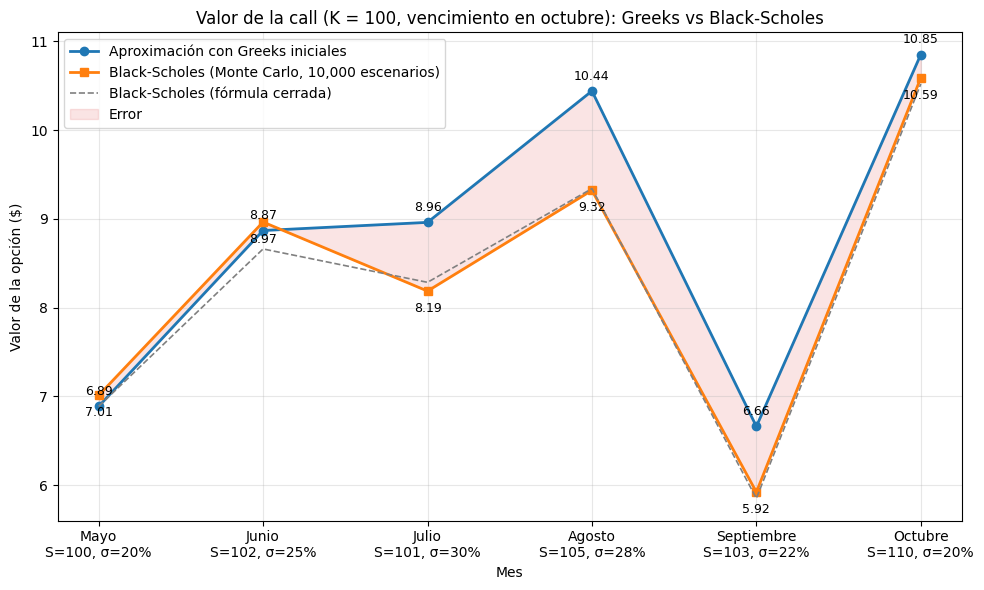

In [ ]:
x = np.arange(len(meses))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, V_greeks, marker="o", linewidth=2, label="Aproximación con Greeks iniciales")
ax.plot(x, V_mc, marker="s", linewidth=2, label="Black-Scholes (Monte Carlo, 10,000 escenarios)")
ax.plot(x, V_bs, linestyle="--", color="gray", linewidth=1.2, label="Black-Scholes (fórmula cerrada)")
ax.fill_between(x, V_greeks, V_mc, color="tab:red", alpha=0.12, label="Error")
for i in x:
    ax.annotate(f"{V_greeks[i]:.2f}", (i, V_greeks[i]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
    ax.annotate(f"{V_mc[i]:.2f}", (i, V_mc[i]), textcoords="offset points", xytext=(0, -15), ha="center", fontsize=9)
ax.set_xticks(x, [f"{m}\nS={s:.0f}, σ={v:.0%}" for m, s, v in zip(meses, S, sigma)])
ax.set_title("Valor de la call (K = 100, vencimiento en octubre): Greeks vs Black-Scholes")
ax.set_ylabel("Valor de la opción ($)")
ax.set_xlabel("Mes")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("greeks_vs_black_scholes.png", dpi=150)
plt.show()

In [ ]:
# Diagnostico: como cambian los Greeks "verdaderos" a lo largo de la trayectoria
def greeks_bs(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100               # por 1 pp
    theta = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    return delta, gamma, vega, theta

d, g, v, th = greeks_bs(S, K, r, sigma, T_rest)
pd.DataFrame({"Mes": meses, "Delta": d, "Gamma": g, "Vega (por pp)": v, "Theta (anual)": th}).round(4)

,Mes,Delta,Gamma,Vega (por pp),Theta (anual)
0,Mayo,0.5977,0.0274,0.2736,-8.1160
1,Junio,0.6302,0.0229,0.2485,-10.2374
2,Julio,0.5949,0.0222,0.2260,-12.7608
3,Agosto,0.6942,0.0239,0.1841,-13.4876
4,Septiembre,0.6797,0.0387,0.1504,-13.1365
5,Octubre,0.9601,0.0135,0.0273,-8.0315


### 3.4 Preguntas

**1. ¿Los Greeks iniciales describen con precisión toda la trayectoria?**
No. Funcionan bien en **junio**, que está cerca del punto inicial (dS = 2, dσ = 5 pp, 1 mes): el error es de ≈ \$0.10–0.20 (≈ 2 %), del orden del ruido de la simulación. Conforme la trayectoria se aleja de mayo, el error crece y la aproximación **sobreestima sistemáticamente** el valor de la opción (julio ≈ 0.7, agosto ≈ 1.1, septiembre ≈ 0.8, contra la fórmula cerrada). Los Greeks son una "fotografía" local del punto (S = 100, σ = 20 %, T = 0.5). La tabla de diagnóstico muestra que los Greeks reales cambian mucho: en septiembre Vega ya vale ≈ 0.16 en lugar de 0.28 y Theta ≈ −12 en lugar de −8.

**2. ¿En qué mes apareció el error más grande?**
En **agosto** (error absoluto ≈ 1.1, ≈ 12 % del valor real). En términos *relativos*, el peor es septiembre (≈ 14 %), porque la opción vale menos y Theta, que se acelera, pesa más. Es el mes que combina tres desviaciones grandes a la vez: la acción subió \$5, la volatilidad sigue 8 pp arriba y ya pasaron 3 meses (a la opción le queda la mitad de su vida).

**3. ¿Qué factor parece contribuir más al error?**
El **paso del tiempo**, que vuelve obsoletos los Greeks, y sobre todo su efecto sobre la **Vega**:
- El término Vega·dσ llega a sumar +2.25 (agosto) y +2.81 (julio), calculado con la Vega de mayo (0.28). Con menos tiempo al vencimiento la Vega real es menor (∝ √T): ≈ 0.20 en julio/agosto. Por eso la aproximación le asigna demasiado valor al aumento de volatilidad.
- Theta se supone constante (lineal en el tiempo), pero el decaimiento se **acelera** cerca del vencimiento. Esto explica que en septiembre, con dσ pequeño, siga habiendo sobreestimación.
- En cambio, el término de precio (Delta + Gamma) funciona razonablemente bien: incluso en octubre, con dS = 10, el error es pequeño porque Gamma corrige la curvatura y la volatilidad regresó a 20 % (dσ = 0), eliminando la fuente principal de error. Aun así, esto es parcialmente una **compensación**: el precio sube y la opción queda ITM, Delta se acerca a 1 y Gamma pierde relevancia.

En resumen, el error lo dominan los meses con **volatilidad alejada de la inicial y mucho tiempo transcurrido** (Vega y Theta fuera de su punto de cálculo), más que el movimiento del precio.

**4. ¿Por qué los Greeks funcionan mejor para movimientos pequeños que para grandes?**
Porque son **derivadas**: describen la pendiente (y la curvatura, en el caso de Gamma) de la función de valor *en un punto*. La expansión de Taylor ignora los términos de orden superior (Speed, Vanna = ∂Δ/∂σ, Volga = ∂Vega/∂σ, Charm = ∂Δ/∂t, etc.) y los términos cruzados, que crecen como (dS)², dS·dσ, (dσ)², dσ·dt... Con cambios pequeños esos términos son despreciables. Con cambios grandes dominan, y los Greeks cambian a lo largo del camino. Es como aproximar una curva con su recta tangente: excelente cerca del punto de contacto, mala lejos de él.

**5. Si la trayectoria fuera mucho más volátil, ¿esperarías errores menores?**
No, **esperaría errores mayores**. Más volatilidad significa movimientos más grandes en S y en σ, por lo que los términos omitidos de la expansión pesan más. Además, la opción cruzaría varias veces la zona ATM, donde Gamma cambia más rápido. Sólo una trayectoria más volátil que **se rebalancee con frecuencia** (recalculando los Greeks cada día, como hace un *trader* que cubre en Delta) mantendría el error bajo. El problema no es la volatilidad en sí, sino usar Greeks viejos para movimientos grandes.

**6. Conclusión**
- Los Greeks son herramientas de **gestión de riesgo local**: dicen cuánto se moverá la opción ante un cambio pequeño de una variable, con todo lo demás constante. Sirvieron para decidir en la Parte 2: A (Delta alta, Theta alta) ≈ sustituto apalancado de la acción; B (ATM) ≈ convexidad; C (Vega alta, Theta baja) ≈ apuesta a volatilidad/eventos.
- Como **modelo de valuación a lo largo de un horizonte de meses**, los Greeks iniciales no bastan: sobreestimaron el valor hasta en ≈ \$1.1 (≈ 12 %). La causa principal es que suponen constantes a Vega y Theta mientras el tiempo al vencimiento se reduce a la mitad.
- La práctica correcta es **recalcular los Greeks periódicamente** (o revaluar con Black-Scholes o Monte Carlo) después de cambios grandes en precio, volatilidad o tiempo. Para decisiones, conviene analizar los Greeks en conjunto y en relación con la prima (Vega/Prima, Theta/Prima), no aislados.